<div dir='rtl'>
<h2> K-means vs GMM (۳۰ نمره)</h2> 


---


در این تمرین قصد داریم دو روش 
kmeans 
و 
GMM
را بدون استفاده از کتابخانه‌های آماده پیاده‌سازی کنیم. 

برای پیاده‌سازی GMM
می‌توانید از تابع نرمال چند متغیره که در 
<code> scipy </code>
است، استفاده کنید.

</div>

<div dir='rtl'>

برای پیاده‌سازی الگوریتم 
K-means
کار را تا جایی ادامه دهید که مرکز خوشه‌ها تغییر نکند.

در پیاده‌سازی الگوریتم GMM
هم تا جایی پیش‌بروید که تفاوت درست‌نمایی در دو دور متوالی کمتر از ۰.۱ باشد.

</div>

<div dir='rtl'>
<h4> الف (۲۰ نمره)</h4>

با استفاده از تابع زیر دیتاست را ایجاد کنید. سپس برای
K=2
دو الگوریتم را روی دیتاست اجرا کنید. 

کیفیت روش‌های پیاده‌سازی شده را با استفاده از دو معیار 
<code> purity </code>
و 
<code> rand-index </code>
با یکدیگر مقایسه کنید.


---


در روش K-means
بهتر است اجرا چند بار انجام شود و بهترین نتیجه گزارش شود.
</div>

In [147]:
import numpy as np
from scipy.stats import norm, multivariate_normal
from scipy.special import comb
from collections import Counter
from itertools import combinations

import matplotlib.pyplot as plt
from matplotlib import style
style.use('ggplot')

from sklearn.datasets import make_classification
from sklearn.datasets.samples_generator import make_moons
from sklearn.datasets.samples_generator import make_circles

In [148]:
class K_Means:
    def __init__(self, k=5, max_iter=300):
        self.k = k
        self.max_iter = max_iter

    def fit(self, data):

        self.centroids = {}

        # dd = data.std(axis = 0) * np.random.rand(self.k, data.shape[1]) + data.mean(axis = 0)
        idx = np.random.randint(X.shape[0], size=self.k)
        dd = X[idx, :]

        for i in range(self.k):
            self.centroids[i] = dd[i]

        for i in range(self.max_iter):
            self.classifications = {}

            for i in range(self.k):
                self.classifications[i] = []

            for g, featureset in enumerate(data):
                distances = [np.linalg.norm(featureset-self.centroids[centroid]) for centroid in self.centroids]
                classification = distances.index(min(distances))
                self.classifications[classification].append(g)

            prev_centroids = dict(self.centroids)

            for classification in self.classifications:
                gg = np.array([data[g] for g in self.classifications[classification]])
                self.centroids[classification] = np.average(gg,axis=0)

            optimized = True

            for c in self.centroids:
                original_centroid = prev_centroids[c]
                current_centroid = self.centroids[c]
                if np.sum((current_centroid-original_centroid)/original_centroid*100.0) > 0:
                    # print(np.sum((current_centroid-original_centroid)/original_centroid*100.0))
                    optimized = False

            if optimized:
                break

In [149]:
def knn_plot(model, X):
    colors = {0:'hotpink', 1: 'aquamarine', 2: 'midnightblue', 3: 'gold', 4:'slategray'}
    for classification in model.classifications:
        color = colors[classification]
        for featureset in X[model.classifications[classification]]:
            plt.scatter(featureset[0], featureset[1], color=color)

    for centroid in model.centroids:
        plt.scatter(model.centroids[centroid][0], model.centroids[centroid][1],
                    marker="x", color="red", s=150, linewidths=4)
    plt.show()

In [150]:
class GMM:

    def __init__(self, clusters, iterations, tolerance, randnum):
        self.clusters = clusters
        self.iterations = iterations
        self.tolerance = tolerance
        self.randnum = randnum

    def fit(self, X):
        rows, cols = X.shape
        self.posterior = np.zeros((rows, self.clusters))

        np.random.seed(self.randnum)
        rand_samples = np.random.choice(rows, self.clusters, replace=False)
        self.means = X[rand_samples]
        self.weights = np.full(self.clusters, 1 / self.clusters)

        shape = self.clusters, cols, cols
        self.covs = np.full(shape, np.cov(X, rowvar=False))

        ll_old = 0
        self.done = False
        self.log_likelihood_trace = []

        for i in range(self.iterations):
            ll_new = self.estep(X)
            self.mstep(X)

            if abs(ll_new - ll_old) <= self.tolerance:
                self.done = True
                break
            ll_old = ll_new
            self.log_likelihood_trace.append(ll_old)

        return self

    def estep(self, X):

        self.log_likelihood(X)
        log_likelihood = np.sum(np.log(np.sum(self.posterior, axis=1)))

        self.posterior = self.posterior / self.posterior.sum(axis=1, keepdims=1)
        return log_likelihood

    def log_likelihood(self, X):
        for k in range(self.clusters):
            prior = self.weights[k]
            likelihood = multivariate_normal(self.means[k], self.covs[k]).pdf(X)
            self.posterior[:, k] = prior * likelihood

        return self

    def mstep(self, X):
        post_weights = self.posterior.sum(axis=0)
        self.weights = post_weights / X.shape[0]

        weighted_sum = np.dot(self.posterior.T, X)
        self.means = weighted_sum / post_weights.reshape(-1, 1)
        for k in range(self.clusters):
            minus = (X - self.means[k]).T
            weighted_sum = np.dot(self.posterior[:, k] * minus, minus.T)
            self.covs[k] = weighted_sum / post_weights[k]

        return self

In [151]:
def plot_gmm(data, means, covs):
    plt.figure()
    gmm_classes = np.argmax(gmm.posterior, axis=1)
    colors = {0:'hotpink', 1: 'aquamarine', 2: 'midnightblue', 3: 'gold', 4:'slategray'}
    for j, x in enumerate(X):
        plt.scatter(x[0], x[1], color=colors[gmm_classes[j]])
    # plt.plot(data[:, 0], data[:, 1], 'ko', color=)

    delta = 0.025
    k = means.shape[0]
    x = np.arange(-2.0, 2.0, delta)
    y = np.arange(-2.0, 2.0, delta)
    x_grid, y_grid = np.meshgrid(x, y)
    coordinates = np.array([x_grid.ravel(), y_grid.ravel()]).T

    col = ['orange', 'plum', 'blue']
    for i in range(k):
        mean = means[i]
        cov = covs[i]
        z_grid = multivariate_normal(mean, cov).pdf(coordinates).reshape(x_grid.shape)
        plt.contour(x_grid, y_grid, z_grid, colors = col[i])

    plt.show()


In [152]:
X, Y = make_classification(n_samples=700, n_features=2,
                           n_informative=2, n_redundant=0,
                           n_classes=2)
print(X.shape)
print(Y.shape)

(700, 2)
(700,)


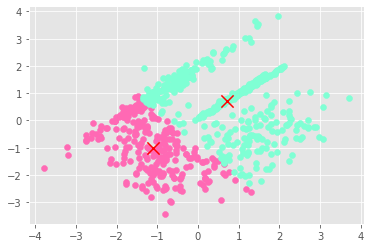

In [153]:
model = K_Means(k=2)
model.fit(X)
knn_plot(model, X)

model = K_Means(k=2)
model.fit(X)
knn_plot(model, X)

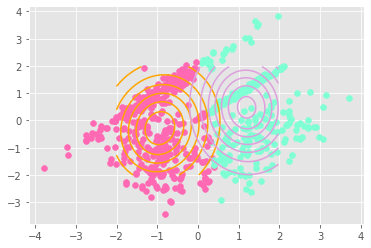

In [154]:
gmm = GMM(clusters = 2, iterations = 100, tolerance = 1e-1, randnum = 4)
gmm.fit(X)
plot_gmm(X, gmm.means, gmm.covs)

In [155]:
def purity(predicted, real):
    d = dict(Counter(zip(predicted, real)))
    n = len(real)
    confusion_mat = np.array([[0. for j in range(n)] for i in range(n)])
    for i in range(n):
        for j in range(n):
            if (i, j) in d.keys():
                confusion_mat[i][j] = d[(i, j)]
            else:
                confusion_mat[i][j] = 0.
    return sum(np.max(confusion_mat, axis=1)) / len(predicted)

In [156]:
def check_clusterings(labels_true, labels_pred):
    labels_true = np.asarray(labels_true)
    labels_pred = np.asarray(labels_pred)    
    return labels_true, labels_pred

def rand_index (labels_pred, labels_true):
    check_clusterings(labels_true, labels_pred)
    my_pair = list(combinations(range(len(labels_true)), 2)) 
    def is_equal(x):
        return (x[0]==x[1])
    my_a = 0
    my_b = 0
    for i in range(len(my_pair)):
            if(is_equal((labels_true[my_pair[i][0]],labels_true[my_pair[i][1]])) == is_equal((labels_pred[my_pair[i][0]],labels_pred[my_pair[i][1]])) 
               and is_equal((labels_pred[my_pair[i][0]],labels_pred[my_pair[i][1]])) == True):
                my_a += 1
            if(is_equal((labels_true[my_pair[i][0]],labels_true[my_pair[i][1]])) == is_equal((labels_pred[my_pair[i][0]],labels_pred[my_pair[i][1]])) 
               and is_equal((labels_pred[my_pair[i][0]],labels_pred[my_pair[i][1]])) == False):
                my_b += 1
    my_denom = comb(len(labels_true),2)
    ri = (my_a + my_b) / my_denom
    return ri

In [157]:
knn_classes = np.zeros((X.shape[0],))
for k, v in model.classifications.items():
    knn_classes[v] = k
knn_classes = knn_classes.astype(int)
gmm_classes = np.argmax(gmm.posterior, axis=1)
print("Purity")
print("KNN:", purity(knn_classes, Y))
print("GMM:", purity(gmm_classes, Y))
print("Rand index")
print("KNN:", rand_index(knn_classes, Y))
print("GMM", rand_index(gmm_classes, Y))

Purity
KNN: 0.7314285714285714
GMM: 0.8857142857142857
Rand index
KNN: 0.6065563049254037
GMM 0.7972613938279174


<div dir='rtl'>
<h3>ب (۱۰ نمره)</h3>

با استفاده از دستورات زیر دیتاست جدید ایجاد کنید. سپس الگوریتم‌های 
Kmeans
و 
GMM
را روی آن‌ها اجرا کنید

در نهایت نتیجه‌ی خوشه‌بندی را بصری‌سازی کنید و نتایج بدست آمده را با هم مقایسه نمایید.


---

برای بصری‌سازی می‌توانید از کتابخانه‌های آماده استفاده کنید.
</div>

In [158]:
X, Y = make_moons(n_samples=700, noise=0.2)

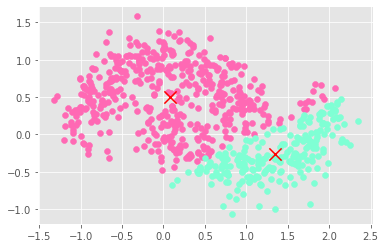

In [159]:
model = K_Means(k=2)
model.fit(X)
knn_plot(model, X)

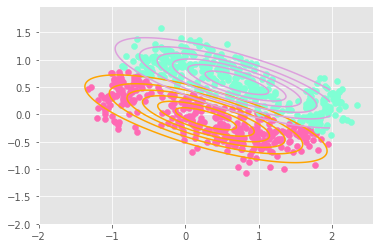

In [160]:
gmm = GMM(clusters = 2, iterations = 100, tolerance = 1e-1, randnum = 4)
gmm.fit(X)
plot_gmm(X, gmm.means, gmm.covs)

In [161]:
X, Y = make_circles(n_samples=700, noise=0.2)

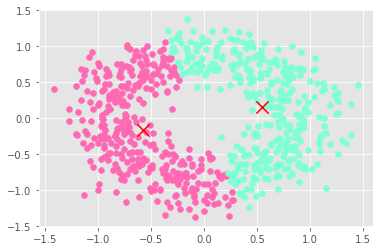

In [162]:
model = K_Means(k=2)
model.fit(X)
knn_plot(model, X)

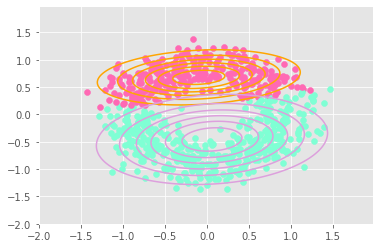

In [163]:
gmm = GMM(clusters = 2, iterations = 100, tolerance = 1e-1, randnum = 4)
gmm.fit(X)
plot_gmm(X, gmm.means, gmm.covs)
# print(X.shape)
# print(gmm.resp.shape)  # num of data * num of classes